In [1]:
# reload modules before execution (for the changing code in Src)
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

SRC_FOLDER = Path(Path.cwd().parent / "src").resolve()
sys.path.append(str(SRC_FOLDER))
import preparation

UTILS_FOLDER = Path(Path().cwd().parent.parent / "rabbit_holes" / "src").resolve()
sys.path.append(str(UTILS_FOLDER))
import plotting_tools

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

In [3]:
PROCESSED_DATA_FOLDER = Path("../Data/Processed/").resolve()
bicliques_fn = "bicliques_wave_5.csv"
data_fn = "base_values_wave_5.parquet"
data, complete_data = preparation.import_bicliques(PROCESSED_DATA_FOLDER / data_fn, PROCESSED_DATA_FOLDER / bicliques_fn)
labels = pd.read_csv(PROCESSED_DATA_FOLDER / "clusters_4.csv", index_col=0)

In [4]:
subm_most_rows = complete_data[0]
la_idx, subm_largest_area = max(enumerate(complete_data), key=lambda pair: pair[1].size)

# Cluster visualization

In [5]:
X = StandardScaler().fit_transform(subm_most_rows)
X_PCA = PCA().fit_transform(X)
X_tSNE = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        #random_state=42
    ).fit_transform(X)

Y = StandardScaler().fit_transform(subm_largest_area)
Y_PCA = PCA().fit_transform(Y)
Y_tSNE = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        #random_state=42
    ).fit_transform(Y)

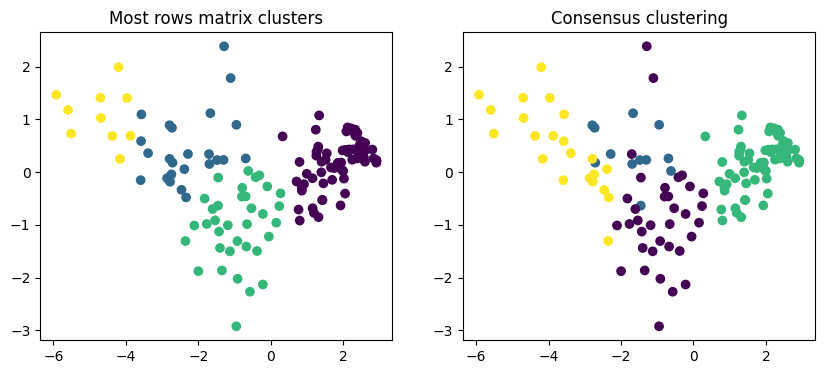

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X_PCA[:, 0], X_PCA[:, 1], c=labels['0'])
ax[0].set_title("Most rows matrix clusters")

ax[1].scatter(X_PCA[:, 0], X_PCA[:, 1], c=labels['final'])
ax[1].set_title("Consensus clustering")
plt.show()

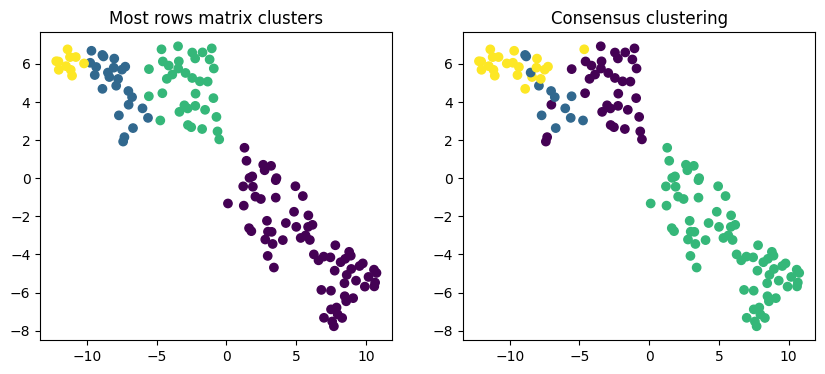

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X_tSNE[:, 0], X_tSNE[:, 1], c=labels['0'])
ax[0].set_title("Most rows matrix clusters")

ax[1].scatter(X_tSNE[:, 0], X_tSNE[:, 1], c=labels['final'])
ax[1].set_title("Consensus clustering")
plt.show()

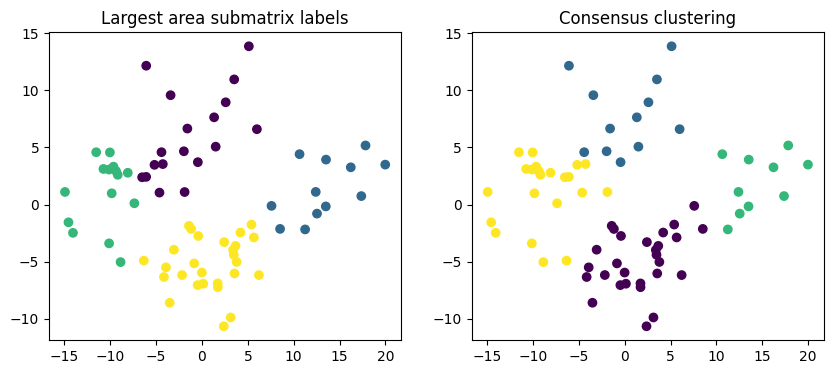

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(Y_PCA[:, 0], Y_PCA[:, 1], c=labels.loc[subm_largest_area.index, str(la_idx)])
ax[0].set_title("Largest area submatrix labels")

ax[1].scatter(Y_PCA[:, 0], Y_PCA[:, 1], c=labels.loc[subm_largest_area.index, "final"])
ax[1].set_title("Consensus clustering")
plt.show()

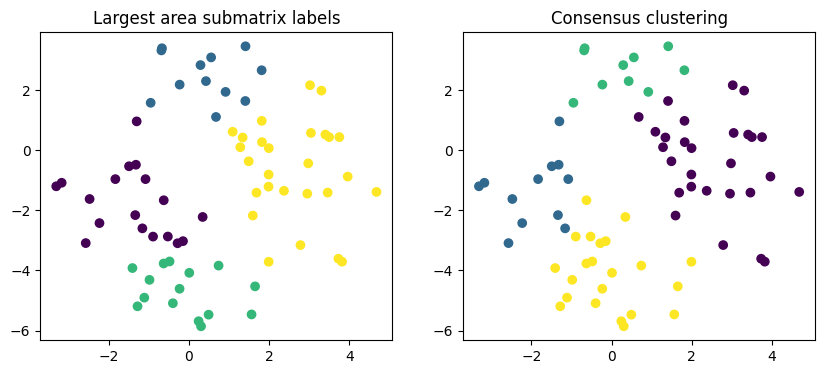

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(Y_tSNE[:, 0], Y_tSNE[:, 1], c=labels.loc[subm_largest_area.index, str(la_idx)])
ax[0].set_title("Largest area submatrix labels")

ax[1].scatter(Y_tSNE[:, 0], Y_tSNE[:, 1], c=labels.loc[subm_largest_area.index, "final"])
ax[1].set_title("Consensus clustering")
plt.show()

# Cluster profiling

In [10]:
final_cluster_profiles = (
    data.assign(final=labels['final'])
    .groupby(by='final')
    .agg(["mean", "median", "std"])
)

In [11]:
final_cluster_profiles.loc[:, subm_most_rows.columns]

series_id account.t.d                             con1                        \
                 mean     median        std       mean     median        std   
final                                                                          
0           50.094472  50.182422  14.804547  86.216863  86.358704   6.984147   
1           70.559531  70.441840   9.011230  83.965255  84.979918   4.939330   
2           88.959253  91.061004   9.830669  95.035452  95.249153   2.994475   
3           43.688759  49.175939  13.257314  70.628341  72.558418  13.270045   

series_id      con9a                       fiaccount.t.d             \
                mean     median        std          mean     median   
final                                                                 
0          69.579182  69.277685  10.294429     46.911017  43.378976   
1          45.998889  47.048105  11.220493     39.082288  40.172730   
2          85.810464  86.640704   6.783188     88.625785  91.061004   
3          29.845869  27.557801  14.314759     21.281025  18.364395   

series_id              fin2.t.d                         internet             \
                 std       mean     median        std       mean     median   
final                                                                         
0          15.140689  30.686253  29.948638  11.572267  74.840746  77.522886   
1          13.752432  23.208958  18.834092  14.306681  51.356844  49.419921   
2          10.137216  80.663380  81.775160  13.678413  89.827352  90.227809   
3           9.813560   8.058047   7.329757   4.263472  31.780658  32.416668   

series_id             
                 std  
final                 
0          12.406547  
1          11.120690  
2           6.207893  
3          12.685151

In [12]:
most_rows_cluster_profiles = (
    subm_most_rows.assign(labels=labels["0"])
    .groupby(by='labels')
    .agg(["mean", "median", "std"])
)

In [13]:
most_rows_cluster_profiles

series_id account.t.d                             con1                       \
                 mean     median        std       mean     median       std   
labels                                                                        
0           88.959253  91.061004   9.830669  95.035452  95.249153  2.994475   
1           62.313066  60.432453  13.912840  81.023113  80.880388  6.014348   
2           48.415854  46.457314  13.593518  87.311712  87.312934  5.628000   
3           37.110511  38.917266  14.385166  57.853210  58.493673  6.569878   

series_id      con9a                       fiaccount.t.d             \
                mean     median        std          mean     median   
labels                                                                
0          85.810464  86.640704   6.783188     88.625785  91.061004   
1          40.982577  44.345680  10.693630     36.692270  32.694960   
2          70.569408  69.277685   8.269016     43.276369  42.461132   
3          19.035602  19.295341   7.699895     18.376820  14.442673   

series_id              fin2.t.d                         internet             \
                 std       mean     median        std       mean     median   
labels                                                                        
0          10.137216  80.663380  81.775160  13.678413  89.827352  90.227809   
1          20.469277  18.218162  13.355584  13.535548  42.618507  43.646678   
2          12.333343  29.393086  28.413178  12.165424  76.548714  77.522886   
3          11.377875   6.380951   4.653570   4.465318  23.283357  23.805130   

series_id            
                std  
labels               
0          6.207893  
1          9.230638  
2          9.304935  
3          9.870356

# Regression

In [14]:
import statsmodels.formula.api as smf

In [15]:
def etas_ols(data, labels):
    etas = []
    
    for feature in data.columns:
        feature_data = (
            data[[feature]]
            .rename(columns={feature:"value"})
            .assign(label=labels)
            .dropna()
        )
    
        model = smf.ols(
            "value ~ C(label)",
            data=feature_data
        ).fit()
    
        eta_sq = model.rsquared
    
        etas.append({
            "feature": feature,
            "eta_2": eta_sq
        })

    return pd.DataFrame(etas)

In [16]:
etas_ols(subm_most_rows, labels["0"])

,feature,eta_2
0,account.t.d,0.736146
1,con1,0.824975
2,con9a,0.880072
3,fiaccount.t.d,0.806797
4,fin2.t.d,0.846724
5,internet,0.888201


In [17]:
etas_ols(subm_most_rows, labels["final"])

,feature,eta_2
0,account.t.d,0.743791
1,con1,0.625873
2,con9a,0.827710
3,fiaccount.t.d,0.840795
4,fin2.t.d,0.861961
5,internet,0.832913


In [19]:
feature_etas = etas_ols(data, labels["final"])
feature_etas.rename(columns={"eta_2": "eta_2_final"}, inplace=True)
feature_etas = pd.merge(feature_etas, etas_ols(data, labels["0"]), left_index=True, right_index=True)
feature_etas["delta_eta_2"] = feature_etas["eta_2"] - feature_etas["eta_2_final"]

C:\Users\mbr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\mbr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\mbr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\mbr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [20]:
feature_etas["delta_eta_2"].describe()

count    278.000000
mean      -0.028751
std        0.111069
min       -0.408797
25%       -0.064834
50%       -0.011356
75%        0.019995
max        0.333897
Name: delta_eta_2, dtype: float64

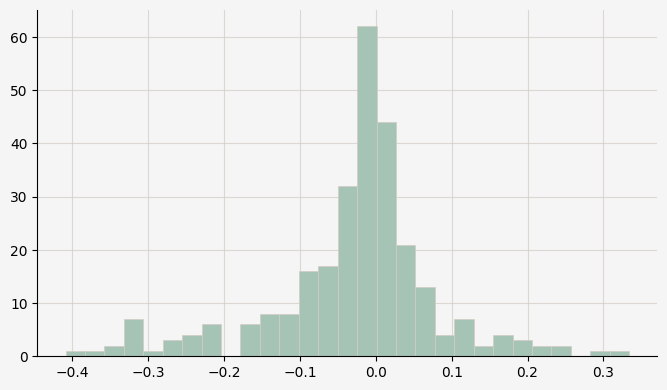

In [21]:
plotting_tools.pretty_histogram(feature_etas["delta_eta_2"])